# 04 — Model Comparison

Extend the baseline by adding NLP features and tree-based models.

**Inputs:** `derived/features.parquet`, `data/merged_books.csv`, `derived/baseline_pipeline.pkl`  
**Outputs:** model comparison table, ROC curves

## Models

| Model | Features | Notes |
|-------|----------|-------|
| Logistic regression | Structural | From notebook 03 — the floor |
| LR + description length & sentiment | Structural + NLP-lite | Fast; no GPU needed |
| Random forest | Structural | Handles non-linearity; built-in feature importance |
| Gradient boosting | Structural | Typically stronger than RF on tabular data |
| LR + description embeddings | Structural + embeddings | sentence-transformers; GPU recommended |

All models use the same year-based split (cutoff from notebook 01).
Primary metric: **F1 (macro)**.  Also report ROC-AUC and precision/recall.

In [1]:
# pip install sentence-transformers

(9417, 33) (9417, 46)
Train: 6,329  Test: 3,067
=== Logistic Regression (baseline) ===
                precision    recall  f1-score   support

non-bestseller       0.96      0.78      0.86      2557
    bestseller       0.43      0.82      0.56       510

      accuracy                           0.79      3067
     macro avg       0.69      0.80      0.71      3067
  weighted avg       0.87      0.79      0.81      3067

F1 (bestseller): 0.561   F1 (macro): 0.711
ROC-AUC: 0.865


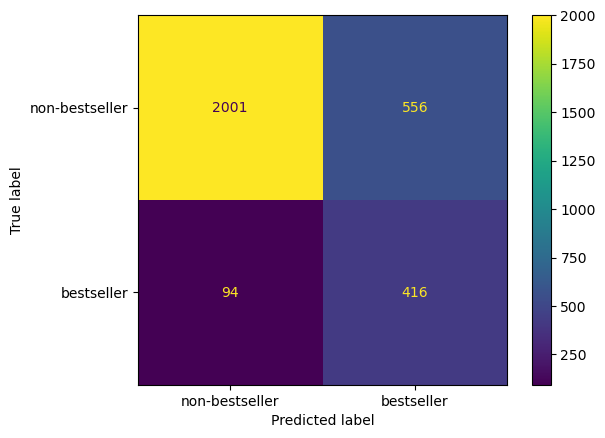

In [2]:
import sys
sys.path.insert(0, '..')

import torch
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import f1_score, precision_score, recall_score

from models.baseline import year_split
from models.evaluate import evaluate_model, compare_models
from features.build_features import (
    description_length,
    description_sentiment,
    description_embeddings,
    build_all_features,
)

TARGET_COL  = 'nyt_bestseller'
CUTOFF_YEAR = 2010  # match notebook 03

DATA_DIR    = Path('..') / 'data'
DERIVED_DIR = Path('..') / 'derived'
RESULTS_DIR = Path('..') / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

X        = pd.read_parquet(DERIVED_DIR / 'features.parquet')
df       = pd.read_csv(DATA_DIR / 'merged_books.csv')
baseline = joblib.load(DERIVED_DIR / 'baseline_pipeline.pkl')

# Rebuild the same split as 03 -- fresh kernel here, so this needs redoing
merged = X.merge(df[['gb_id', 'pub_year', TARGET_COL]], on='gb_id', how='inner')
feature_cols = [c for c in X.columns if c != 'gb_id']
X_train, y_train, X_test, y_test = year_split(merged, feature_cols, TARGET_COL, CUTOFF_YEAR)
print(X.shape, df.shape)
print(f'Train: {len(X_train):,}  Test: {len(X_test):,}')

# Evaluate the already-fitted baseline on this notebook's own test split,
# so it can be compared against every model built below in Section 5
baseline_result = evaluate_model(
    baseline, X_test, y_test, 'Logistic Regression (baseline)',
    save_path=RESULTS_DIR / '04_confusion_matrix_baseline_recheck.png',
)

## 1. Add description length & VADER sentiment

=== LR + description NLP-lite ===
                precision    recall  f1-score   support

non-bestseller       0.95      0.78      0.86      2557
    bestseller       0.42      0.80      0.55       510

      accuracy                           0.78      3067
     macro avg       0.69      0.79      0.71      3067
  weighted avg       0.86      0.78      0.81      3067

F1 (bestseller): 0.553   F1 (macro): 0.706
ROC-AUC: 0.863


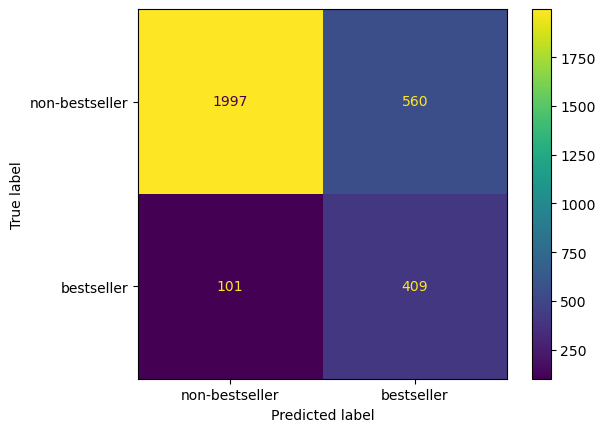

In [3]:
# TODO: append description_length and description_sentiment columns to X
# Fit a new LR pipeline and call evaluate_model
# Compare F1 against baseline — does text metadata help?

sent_feat = description_sentiment(df)  # desc_neg, desc_neu, desc_pos, desc_compound

X_nlp = merged.copy()
sent_with_id = sent_feat.copy()
sent_with_id['gb_id'] = df['gb_id']
X_nlp = X_nlp.merge(sent_with_id, on='gb_id', how='inner')

nlp_feature_cols = feature_cols + ['desc_neg', 'desc_neu', 'desc_pos', 'desc_compound']
X_train_nlp, y_train_nlp, X_test_nlp, y_test_nlp = year_split(
    X_nlp, nlp_feature_cols, TARGET_COL, CUTOFF_YEAR
)

pipeline_nlp = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced")),
])
pipeline_nlp.fit(X_train_nlp, y_train_nlp)

result_lr_nlp = evaluate_model(
    pipeline_nlp, X_test_nlp, y_test_nlp, 'LR + description NLP-lite',
    save_path=RESULTS_DIR / '04_confusion_matrix_lr_nlp.png',
)

## 2. Random forest

=== Random Forest ===
                precision    recall  f1-score   support

non-bestseller       0.92      0.93      0.92      2557
    bestseller       0.61      0.58      0.60       510

      accuracy                           0.87      3067
     macro avg       0.76      0.75      0.76      3067
  weighted avg       0.87      0.87      0.87      3067

F1 (bestseller): 0.596   F1 (macro): 0.759
ROC-AUC: 0.875


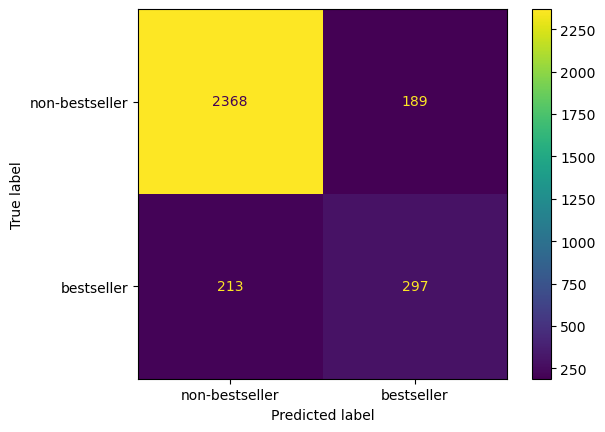

In [4]:
# TODO: fit RandomForestClassifier(class_weight='balanced', n_estimators=300)
# Plot feature importances — compare to LR coefficients from notebook 03

from sklearn.ensemble import RandomForestClassifier

pipeline_rf = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(
        n_estimators=300, class_weight="balanced", random_state=42
    )),
])
pipeline_rf.fit(X_train, y_train)

result_rf = evaluate_model(
    pipeline_rf, X_test, y_test, 'Random Forest',
    save_path=RESULTS_DIR / '04_confusion_matrix_rf.png',
)

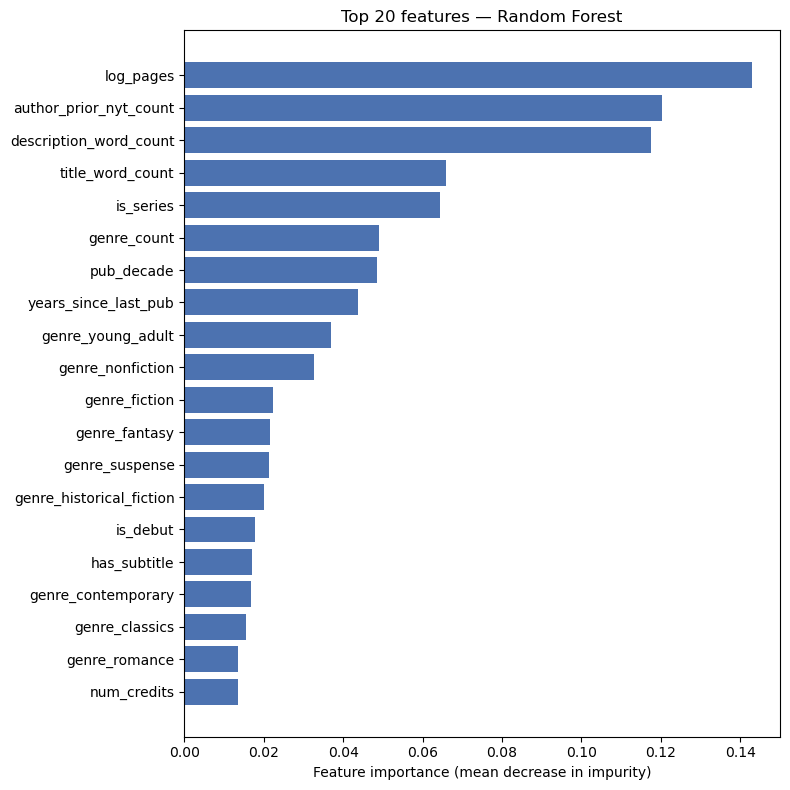

                 feature  importance
               log_pages    0.142849
  author_prior_nyt_count    0.120288
  description_word_count    0.117520
        title_word_count    0.065889
               is_series    0.064340
             genre_count    0.049011
              pub_decade    0.048473
    years_since_last_pub    0.043757
       genre_young_adult    0.037006
        genre_nonfiction    0.032637
           genre_fiction    0.022199
           genre_fantasy    0.021453
          genre_suspense    0.021425
genre_historical_fiction    0.020086
                is_debut    0.017882
            has_subtitle    0.016985
      genre_contemporary    0.016692
          genre_classics    0.015620
           genre_romance    0.013576
             num_credits    0.013504


In [5]:
# Feature importance plot, compared against 03's coefficients

importances = pipeline_rf.named_steps['clf'].feature_importances_
imp_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances,
}).sort_values('importance', ascending=False)

top20_rf = imp_df.head(20)

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(top20_rf['feature'][::-1], top20_rf['importance'][::-1], color='#4C72B0')
ax.set_xlabel('Feature importance (mean decrease in impurity)')
ax.set_title('Top 20 features — Random Forest')
plt.tight_layout()
plt.savefig(RESULTS_DIR / '04_rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(top20_rf.to_string(index=False))

## 3. Gradient boosting

=== Gradient Boosting ===
                precision    recall  f1-score   support

non-bestseller       0.95      0.82      0.88      2557
    bestseller       0.47      0.80      0.59       510

      accuracy                           0.82      3067
     macro avg       0.71      0.81      0.74      3067
  weighted avg       0.87      0.82      0.84      3067

F1 (bestseller): 0.595   F1 (macro): 0.739
ROC-AUC: 0.873


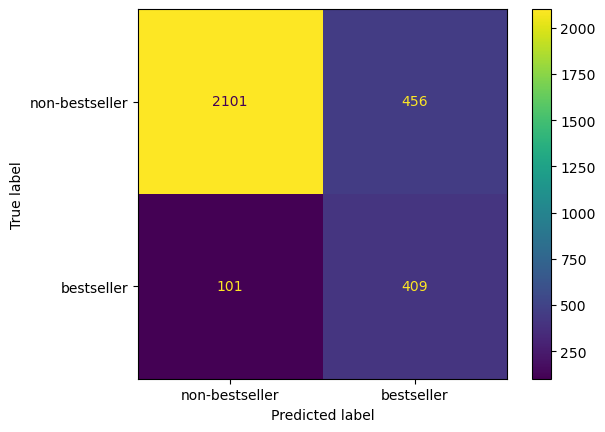

In [6]:
# TODO: fit GradientBoostingClassifier or LightGBM with scale_pos_weight
# Tune max_depth and learning_rate with a small grid search on the train split

from sklearn.ensemble import GradientBoostingClassifier

# Compute per-sample weights to mimic class_weight='balanced'
# (inverse class frequency, same principle sklearn uses internally)
n_pos = y_train.sum()
n_neg = len(y_train) - n_pos
weight_pos = len(y_train) / (2 * n_pos)
weight_neg = len(y_train) / (2 * n_neg)
sample_weight = y_train.map({0: weight_neg, 1: weight_pos})

pipeline_gb = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("clf", GradientBoostingClassifier(random_state=42)),
])
pipeline_gb.fit(X_train, y_train, clf__sample_weight=sample_weight)

result_gb = evaluate_model(
    pipeline_gb, X_test, y_test, 'Gradient Boosting',
    save_path=RESULTS_DIR / '04_confusion_matrix_gb.png',
)

**Hyperparameter tuning attempt:**
A small grid search over max_depth/learning_rate,
validated on a temporal slice of the training years (2005–2009), selected parameters that
underperformed the untuned sklearn defaults on the real 2010+ test set (F1 0.579 vs. 0.595).
Likely cause: the tuning-validation slice is small and doesn't include the 2015–2017
rate-drift period found in EDA, so it's an imperfect proxy for the real test distribution.
The untuned Gradient Boosting model is used in the final comparison instead.

In [7]:
# ── Quick grid search for Gradient Boosting — tuned on a slice of TRAIN years only ──
# Never touches the real 2010+ test set during tuning (avoids "overfitting the split").

TUNE_CUTOFF = 2005  # tune-train: pub_year < 2005; tune-val: 2005 <= pub_year < 2010

train_only = merged[merged['pub_year'] < CUTOFF_YEAR]
X_tune_train, y_tune_train, X_tune_val, y_tune_val = year_split(
    train_only, feature_cols, TARGET_COL, TUNE_CUTOFF
)
print(f'Tune-train: {len(X_tune_train):,} rows, {y_tune_train.sum()} positives')
print(f'Tune-val:   {len(X_tune_val):,} rows, {y_tune_val.sum()} positives')

def make_sample_weight(y):
    """Mimic class_weight='balanced' via sample_weight (GB has no class_weight param)."""
    n_pos, n_neg = y.sum(), len(y) - y.sum()
    w_pos, w_neg = len(y) / (2 * n_pos), len(y) / (2 * n_neg)
    return y.map({0: w_neg, 1: w_pos})

param_grid = [{'max_depth': d, 'learning_rate': lr}
              for d in [2, 3, 4] for lr in [0.05, 0.1, 0.2]]

results_grid = []
for params in param_grid:
    imputer = SimpleImputer(strategy="median")
    X_tt_imp = imputer.fit_transform(X_tune_train)
    X_tv_imp = imputer.transform(X_tune_val)

    clf = GradientBoostingClassifier(random_state=42, **params)
    clf.fit(X_tt_imp, y_tune_train, sample_weight=make_sample_weight(y_tune_train))

    f1_val = f1_score(y_tune_val, clf.predict(X_tv_imp))
    results_grid.append({**params, 'f1_val': f1_val})

grid_df = pd.DataFrame(results_grid).sort_values('f1_val', ascending=False)
print(grid_df.to_string(index=False))

best_params = grid_df.iloc[0][['max_depth', 'learning_rate']].to_dict()
best_params['max_depth'] = int(best_params['max_depth'])
print(f'\nBest params: {best_params}')

Tune-train: 4,463 rows, 590 positives
Tune-val:   1,866 rows, 321 positives
 max_depth  learning_rate   f1_val
         3           0.20 0.508876
         2           0.20 0.504673
         2           0.10 0.502604
         3           0.10 0.500728
         4           0.05 0.493314
         2           0.05 0.488127
         4           0.20 0.487395
         4           0.10 0.485317
         3           0.05 0.481375

Best params: {'max_depth': 3, 'learning_rate': 0.2}


=== Gradient Boosting (tuned) ===
                precision    recall  f1-score   support

non-bestseller       0.95      0.83      0.88      2557
    bestseller       0.47      0.76      0.58       510

      accuracy                           0.82      3067
     macro avg       0.71      0.79      0.73      3067
  weighted avg       0.87      0.82      0.83      3067

F1 (bestseller): 0.579   F1 (macro): 0.730
ROC-AUC: 0.859


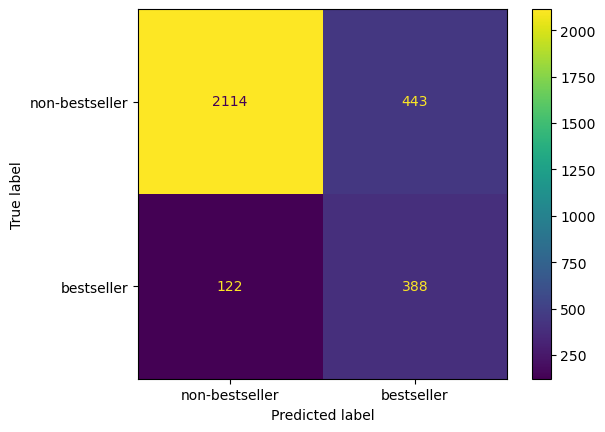

In [8]:
pipeline_gb_tuned = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("clf", GradientBoostingClassifier(random_state=42, **best_params)),
])
pipeline_gb_tuned.fit(X_train, y_train, clf__sample_weight=make_sample_weight(y_train))

result_gb_tuned = evaluate_model(
    pipeline_gb_tuned, X_test, y_test, 'Gradient Boosting (tuned)',
    save_path=RESULTS_DIR / '04_confusion_matrix_gb_tuned.png',
)

## 4. Description embeddings (optional — GPU recommended)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/295 [00:00<?, ?it/s]

Embedding shape: (9417, 384)
Train: 6,329 rows x 416 features
=== LR + description embeddings ===
                precision    recall  f1-score   support

non-bestseller       0.94      0.78      0.85      2557
    bestseller       0.41      0.75      0.53       510

      accuracy                           0.78      3067
     macro avg       0.67      0.77      0.69      3067
  weighted avg       0.85      0.78      0.80      3067

F1 (bestseller): 0.527   F1 (macro): 0.690
ROC-AUC: 0.837


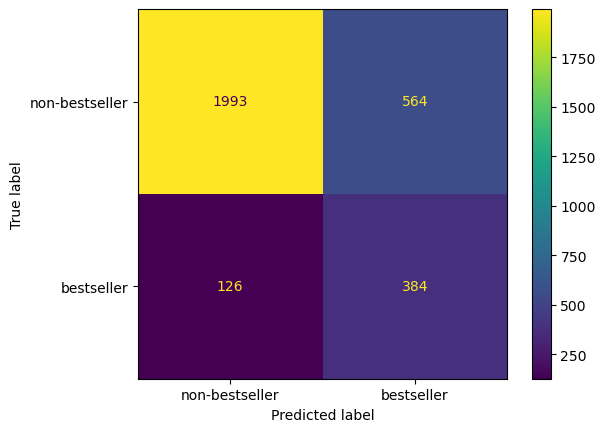

In [9]:
# TODO: call description_embeddings(df, model_name='all-MiniLM-L6-v2')
# Concatenate with structural features
# Optionally debias before training (see sff-predict/models/debias.py)
# Fit LR on concatenated matrix

embeddings = description_embeddings(df, model_name='all-MiniLM-L6-v2')
print('Embedding shape:', embeddings.shape)

emb_df = pd.DataFrame(
    embeddings,
    columns=[f'desc_emb_{i}' for i in range(embeddings.shape[1])]
)
emb_df['gb_id'] = df['gb_id'].values

# Same merge pattern as Section 1 (structural features + this new block, joined on gb_id)
X_emb = merged.merge(emb_df, on='gb_id', how='inner')
emb_feature_cols = feature_cols + [f'desc_emb_{i}' for i in range(embeddings.shape[1])]

X_train_emb, y_train_emb, X_test_emb, y_test_emb = year_split(
    X_emb, emb_feature_cols, TARGET_COL, CUTOFF_YEAR
)
print(f'Train: {len(X_train_emb):,} rows x {len(emb_feature_cols)} features')

pipeline_emb = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced")),
])
pipeline_emb.fit(X_train_emb, y_train_emb)

result_emb = evaluate_model(
    pipeline_emb, X_test_emb, y_test_emb, 'LR + description embeddings',
    save_path=RESULTS_DIR / '04_confusion_matrix_lr_embeddings.png',
)

## 5. Comparison table & ROC curves

In [10]:
# Collect all evaluate_model results into a list
# print(compare_models([baseline_result, lr_nlp_result, rf_result, gb_result, emb_result]))



# Sanity check: all model variants should share the same test-row count,
# since they're all inner-joined from the same base df on gb_id
assert len(X_test) == len(X_test_nlp) == len(X_test_emb), \
    "Test set sizes differ across model variants — check the merges."

naive_results = [
    {
        'model': 'Always-0',
        'f1': f1_score(y_test, np.zeros_like(y_test), zero_division=0),
        'f1_macro': f1_score(y_test, np.zeros_like(y_test), average='macro', zero_division=0),
        'precision': precision_score(y_test, np.zeros_like(y_test), zero_division=0),
        'recall': recall_score(y_test, np.zeros_like(y_test), zero_division=0),
        'roc_auc': None,
    },
    {
        'model': 'Always-1',
        'f1': f1_score(y_test, np.ones_like(y_test), zero_division=0),
        'f1_macro': f1_score(y_test, np.ones_like(y_test), average='macro', zero_division=0),
        'precision': precision_score(y_test, np.ones_like(y_test), zero_division=0),
        'recall': recall_score(y_test, np.ones_like(y_test), zero_division=0),
        'roc_auc': None,
    },
]

# Using the UNTUNED GradientBoosting result (result_gb) -- the tuned version
# underperformed on the real test set and was discarded (documented separately).
all_results = naive_results + [
    baseline_result,
    result_lr_nlp,
    result_rf,
    result_gb,
    result_emb,
]

comparison_all = compare_models(all_results)
print(comparison_all.to_string(index=False))

comparison_all.to_csv(RESULTS_DIR / '04_model_comparison.csv', index=False)
print("\nSaved comparison table to results/04_model_comparison.csv")

                         model       f1  f1_macro  precision   recall  roc_auc
                 Random Forest 0.596386  0.759072   0.611111 0.582353 0.874751
             Gradient Boosting 0.594909  0.738934   0.472832 0.801961 0.873252
Logistic Regression (baseline) 0.561404  0.710839   0.427984 0.815686 0.864651
     LR + description NLP-lite 0.553076  0.705539   0.422085 0.801961 0.862933
   LR + description embeddings 0.526749  0.689593   0.405063 0.752941 0.837440
                      Always-1 0.285155  0.142578   0.166286 1.000000      NaN
                      Always-0 0.000000  0.454659   0.000000 0.000000      NaN

Saved comparison table to results/04_model_comparison.csv


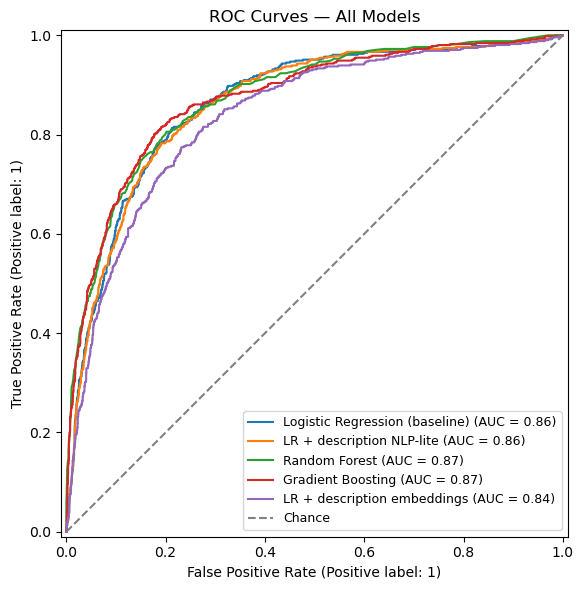

In [11]:
# Plot overlaid ROC curves with model names in the legend
# fig, ax = plt.subplots(figsize=(8, 6))
# for model, name in [(pipeline, 'LR baseline'), ...]:
#     RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)

fig, ax = plt.subplots(figsize=(8, 6))

# Naive baselines deliberately excluded: a fixed-prediction rule has no
# threshold to sweep, so there's no meaningful ROC curve for them --
# they're only comparable in the table above, not this plot.
roc_models = [
    (baseline,      X_test,     y_test,     'Logistic Regression (baseline)'),
    (pipeline_nlp,  X_test_nlp, y_test_nlp, 'LR + description NLP-lite'),
    (pipeline_rf,   X_test,     y_test,     'Random Forest'),
    (pipeline_gb,   X_test,     y_test,     'Gradient Boosting'),
    (pipeline_emb,  X_test_emb, y_test_emb, 'LR + description embeddings'),
]

for model, Xt, yt, name in roc_models:
    RocCurveDisplay.from_estimator(model, Xt, yt, ax=ax, name=name)

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')
ax.set_title('ROC Curves — All Models')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(RESULTS_DIR / '04_roc_curves_all_models.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

| Model | F1 (bestseller) | F1 (macro) | Precision | Recall | ROC-AUC |
|---|---|---|---|---|---|
| Random Forest | **0.596** | 0.759 | 0.61 | 0.58 | 0.875 |
| Gradient Boosting | 0.595 | 0.739 | 0.47 | 0.80 | 0.873 |
| Logistic Regression (baseline) | 0.560 | 0.71 | 0.43 | 0.82 | 0.865 |
| LR + description NLP-lite | 0.553 | 0.706 | 0.42 | 0.80 | 0.863 |
| LR + description embeddings | 0.527 | 0.690 | 0.41 | 0.75 | 0.837 |
| Always-1 (naive) | 0.285 | 0.143 | 0.166 | 1.00 | — |
| Always-0 (naive) | 0.000 | 0.455 | 0.000 | 0.00 | — |

- **Random Forest and Gradient Boosting are effectively tied** on the F1 bestseller
  (0.596 vs 0.595) but with opposite precision/recall character:
  RF is conservative (fewer, higher-confidence positives), GB casts a wider net like LR.
  All three tree/linear-with-balancing approaches sit in a tight ROC-AUC band (0.86–0.88),
  indicating similar underlying discriminative power, differing mainly in decision threshold.
- **Description-based text features did not help, and for embeddings actively hurt** —
  both NLP-lite and full embeddings score below the plain structural baseline. The
  embeddings result is attributed to overfitting (416 features vs. 6,329 training rows,
  a much higher ratio than any other model here), not to text carrying zero signal — we
  separately confirmed `desc_compound` carries real (if modest) information beyond genre.
  A GB hyperparameter tuning attempt was also discarded (underperformed the untuned
  default on the real test set).
- **Best model: Random Forest**, F1 (best-seller)=0.596, F1 (macro)=0.759, clearing the ≥0.40 target by a wide margin.


**Next:** Checkpoint 5 — presentation and communication, built on Random Forest as the final model